# 10g — LLaVA Paired Analysis: VLM vs LM Decoder × Blind vs Inst-Blind

Three LLaVA families with matched VLM + LM decoder pairs:
- **LLaVA-1.5** · **LLaVA-Mistral** · **LLaVA-Vicuna**

Conditions:
- **blind**: blank image, no instruction (VLM only)
- **inst_blind**: blank image + "no image" instruction (VLM + LM)

Key questions:
1. Does the instruction change VLM behavior (blind → inst_blind)?
2. Does removing the vision encoder change behavior (VLM → LM, same inst_blind)?
3. Which questions does vision actually help (VLM acc > LM acc)?

In [1]:
import sys
from pathlib import Path

BASE    = Path('/home/david/Desktop/yuna/HPA')
EXPORTS = BASE / 'analysis/session2/exports'
sys.path.insert(0, str(BASE / 'analysis'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from utils.vqa import preprocess_answer

VARIANT_ORDER  = ['C', 'B', 'A']
VARIANT_COLORS = {'C': '#1E88E5', 'B': '#FB8C00', 'A': '#E53935'}

FAMILIES = {
    'LLaVA-1.5':    {'VLM': 'LLaVA-1.5-7B',  'LM': 'LLaVA-1.5 (LM)'},
    'LLaVA-Mistral':{'VLM': 'LLaVA-Mistral',  'LM': 'LLaVA-Mistral (LM)'},
    'LLaVA-Vicuna': {'VLM': 'LLaVA-Vicuna',   'LM': 'LLaVA-Vicuna (LM)'},
}
FAM_COLORS = {
    'LLaVA-1.5':     '#1565C0',
    'LLaVA-Mistral': '#6A1B9A',
    'LLaVA-Vicuna':  '#BF360C',
}
# Condition → linestyle + marker (used in g0000009 agreement plot)
COND_STYLE = {
    'blind':      dict(ls='--', marker='o', lw=1.5, ms=6, alpha=0.55),
    'inst_blind': dict(ls='-',  marker='s', lw=2.0, ms=7, alpha=0.90),
    'lm':         dict(ls=':',  marker='^', lw=2.0, ms=7, alpha=0.80),
}
# Ordered conditions for g0000004 / g0000005
COND_KEYS   = [('blind', 'VLM'), ('inst_blind', 'VLM'), ('inst_blind', 'LM')]
COND_LABELS = ['VLM blind', 'VLM inst_blind', 'LM inst_blind']

In [2]:
# ── Load data ──────────────────────────────────────────────────────────────────
blind_df = pd.read_csv(EXPORTS / 'responses_model_blind.csv')
inst_df  = pd.read_csv(EXPORTS / 'responses_model_inst_blind.csv')

blind_df['condition'] = 'blind'
inst_df['condition']  = 'inst_blind'

vlm_labels = [f['VLM'] for f in FAMILIES.values()]
lm_labels  = [f['LM']  for f in FAMILIES.values()]

blind_llava = blind_df[blind_df['model'].isin(vlm_labels)].copy()
inst_vlm    = inst_df[inst_df['model'].isin(vlm_labels)].copy()
inst_lm     = inst_df[inst_df['model'].isin(lm_labels)].copy()

label_to_family = {}
label_to_type   = {}
for fam, d in FAMILIES.items():
    label_to_family[d['VLM']] = fam;  label_to_type[d['VLM']] = 'VLM'
    label_to_family[d['LM']]  = fam;  label_to_type[d['LM']]  = 'LM'

combined = pd.concat([blind_llava, inst_vlm, inst_lm], ignore_index=True)
combined['family']     = combined['model'].map(label_to_family)
combined['model_type'] = combined['model'].map(label_to_type)
combined['resp_len']   = combined['response'].fillna('').astype(str).str.split().str.len()
combined['resp_norm']  = combined['response'].apply(lambda x: preprocess_answer(str(x or '')))

print('Blind VLM rows:    ', len(blind_llava), blind_llava['model'].unique().tolist())
print('Inst_blind VLM:    ', len(inst_vlm),    inst_vlm['model'].unique().tolist())
print('Inst_blind LM:     ', len(inst_lm),     inst_lm['model'].unique().tolist())
print('Variants:', combined['variant'].value_counts().to_dict())

Blind VLM rows:     1016 ['LLaVA-1.5-7B', 'LLaVA-Mistral', 'LLaVA-Vicuna']
Inst_blind VLM:     1016 ['LLaVA-1.5-7B', 'LLaVA-Mistral', 'LLaVA-Vicuna']
Inst_blind LM:      1014 ['LLaVA-1.5 (LM)', 'LLaVA-Mistral (LM)', 'LLaVA-Vicuna (LM)']
Variants: {'B': 1017, 'C': 1017, 'A': 1012}


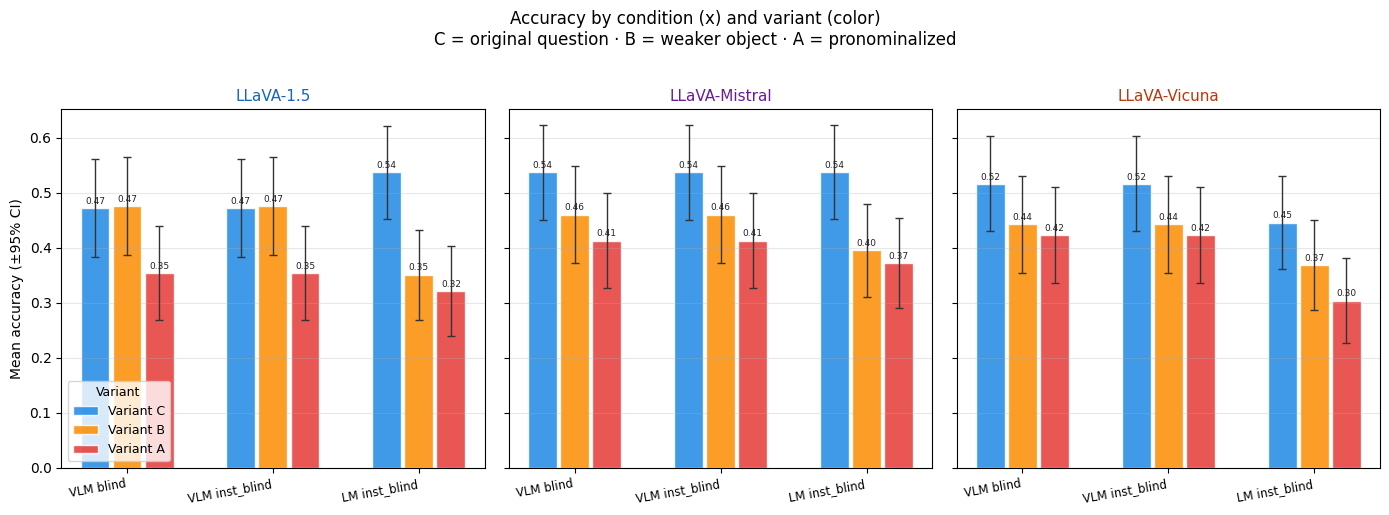

In [3]:
# ── Accuracy by condition × variant — one panel per family ───────────────────
# x = condition (VLM blind / VLM inst_blind / LM inst_blind)
# hue/color = variant (C=blue, B=orange, A=red)
# family = subplots

x_pos = np.arange(len(COND_KEYS))
n_var = len(VARIANT_ORDER)
w = 0.22
offsets = np.array([-w, 0, w])   # C, B, A

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, (fam, d) in zip(axes, FAMILIES.items()):
    for vi, var in enumerate(VARIANT_ORDER):
        vals, errs = [], []
        for cond_key, mtype in COND_KEYS:
            sub = combined[
                (combined['model']     == d[mtype]) &
                (combined['condition'] == cond_key) &
                (combined['variant']   == var)
            ]['accuracy']
            vals.append(sub.mean() if len(sub) else np.nan)
            errs.append(sub.sem()  if len(sub) else 0.0)

        bars = ax.bar(x_pos + offsets[vi], vals, width=w * 0.9,
                      color=VARIANT_COLORS[var], alpha=0.85,
                      edgecolor='white', label=f'Variant {var}')
        ax.errorbar(x_pos + offsets[vi], vals, yerr=[1.96*e for e in errs],
                    fmt='none', ecolor='#333', elinewidth=1, capsize=3)
        for xi, v in enumerate(vals):
            if not np.isnan(v):
                ax.text(xi + offsets[vi], v + 0.004, f'{v:.2f}',
                        ha='center', va='bottom', fontsize=6.5, color='#222')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(COND_LABELS, fontsize=8.5, rotation=10, ha='right')
    ax.set_title(fam, color=FAM_COLORS[fam], fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, None)

axes[0].set_ylabel('Mean accuracy (±95% CI)')
axes[0].legend(title='Variant', fontsize=9, title_fontsize=9)

plt.suptitle('Accuracy by condition (x) and variant (color)\n'
             'C = original question · B = weaker object · A = pronominalized',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

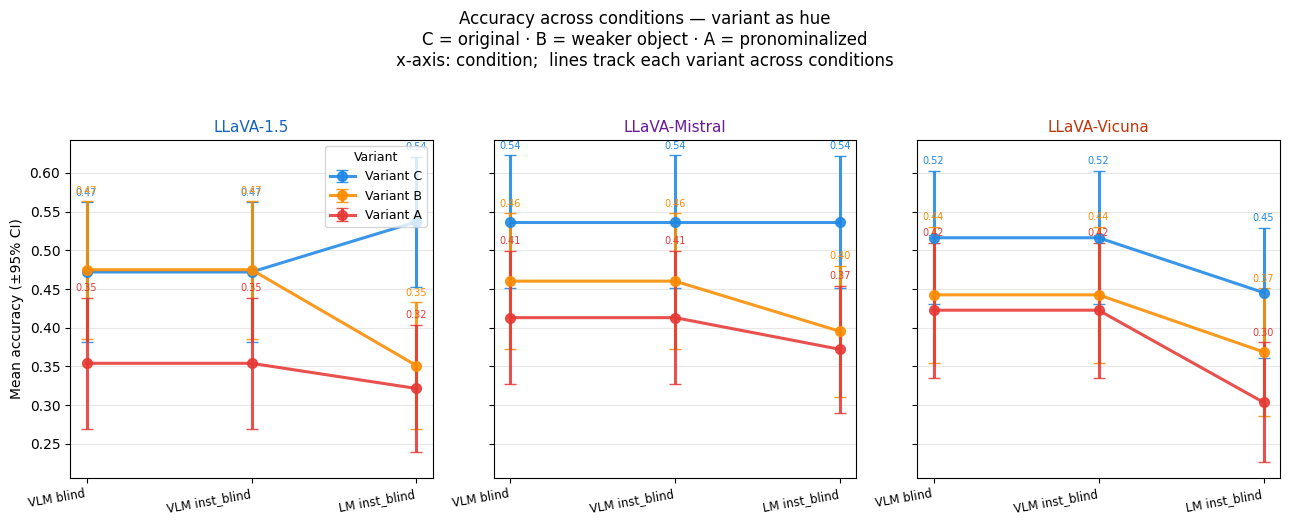

In [4]:
# ── Accuracy across conditions — line plot with variant as hue ─────────────────
# x = condition (VLM blind / VLM inst_blind / LM inst_blind)
# hue/color = variant (C=blue, B=orange, A=red)
# family = subplots

x_pos = np.arange(len(COND_KEYS))
fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)

for ax, (fam, d) in zip(axes, FAMILIES.items()):
    for var in VARIANT_ORDER:
        means, cis = [], []
        for cond_key, mtype in COND_KEYS:
            sub = combined[
                (combined['model']     == d[mtype]) &
                (combined['condition'] == cond_key) &
                (combined['variant']   == var)
            ]['accuracy']
            means.append(sub.mean() if len(sub) else np.nan)
            cis.append(sub.sem() * 1.96 if len(sub) else 0.0)

        ax.errorbar(x_pos, means, yerr=cis,
                    color=VARIANT_COLORS[var], marker='o', lw=2.2, ms=7,
                    capsize=4, label=f'Variant {var}', alpha=0.88)
        for xi, (m, ci) in enumerate(zip(means, cis)):
            if not np.isnan(m):
                ax.text(xi, m + ci + 0.006, f'{m:.2f}',
                        ha='center', va='bottom', fontsize=7,
                        color=VARIANT_COLORS[var])

    ax.set_xticks(x_pos)
    ax.set_xticklabels(COND_LABELS, fontsize=8.5, rotation=10, ha='right')
    ax.set_title(fam, color=FAM_COLORS[fam], fontsize=11)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Mean accuracy (±95% CI)')
axes[0].legend(title='Variant', fontsize=9, title_fontsize=9, loc='upper right')

plt.suptitle('Accuracy across conditions — variant as hue\n'
             'C = original · B = weaker object · A = pronominalized\n'
             'x-axis: condition;  lines track each variant across conditions',
             y=1.04, fontsize=12)
plt.tight_layout()
plt.show()

KeyError: 'resp_norm'

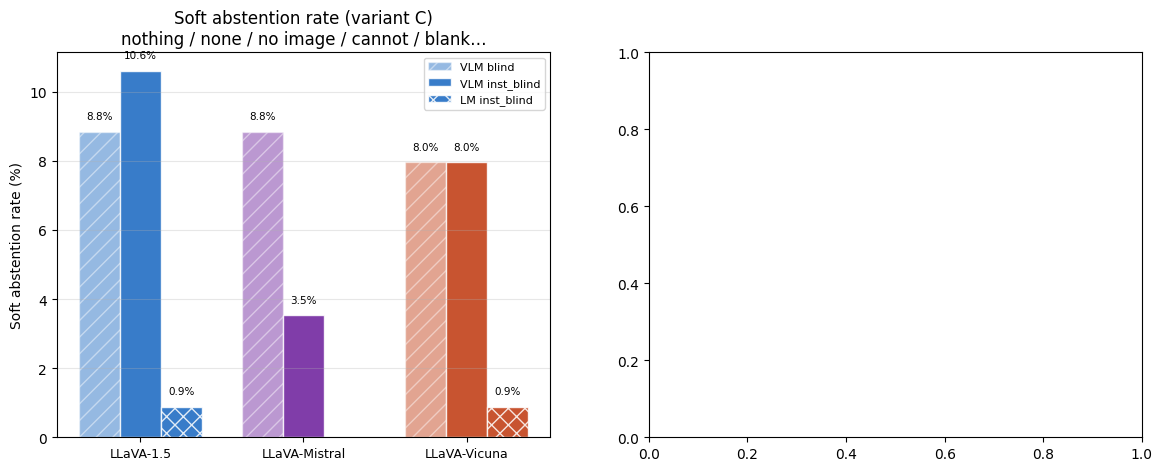

In [5]:
# ── Soft abstention rate + answer flip rate (side by side) ───────────────────
import re

SOFT_RE = re.compile(
    r'\b(nothing|none|nowhere|unanswerable|cannot|can\'t|unable|no image|'
    r'no picture|not visible|not shown|not provided|blank|unclear|unknown|'
    r'impossible|insufficient|n\/a)\b', re.IGNORECASE
)

def soft_rate(series):
    return series.fillna('').astype(str).str.contains(SOFT_RE).mean()

def flip_rate(vlm_label, variant='C'):
    bl = (blind_llava[(blind_llava['model']==vlm_label) & (blind_llava['variant']==variant)]
          .set_index('question_id')['resp_norm'])
    ib = (inst_vlm[(inst_vlm['model']==vlm_label)  & (inst_vlm['variant']==variant)]
          .set_index('question_id')['resp_norm'])
    common = bl.index.intersection(ib.index)
    return (bl[common] != ib[common]).mean() if len(common) else np.nan

C_df = combined[combined['variant'] == 'C']
fams = list(FAMILIES.keys())
x = np.arange(len(fams))
w = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: soft abstention
ax = axes[0]
for ci, (cond_key, cond_label, alpha, hatch) in enumerate([
    ('blind',      'VLM blind',      0.45, '//'),
    ('inst_blind', 'VLM inst_blind', 0.85, ''),
    ('lm',         'LM inst_blind',  0.85, 'xx'),
]):
    vals = []
    for fam in fams:
        d = FAMILIES[fam]
        if cond_key == 'lm':
            sub = C_df[(C_df['model']==d['LM'])  & (C_df['condition']=='inst_blind')]['response']
        elif cond_key == 'blind':
            sub = C_df[(C_df['model']==d['VLM']) & (C_df['condition']=='blind')]['response']
        else:
            sub = C_df[(C_df['model']==d['VLM']) & (C_df['condition']=='inst_blind')]['response']
        vals.append(soft_rate(sub) * 100 if len(sub) else np.nan)
    ax.bar(x + (ci-1)*w, vals, width=w, alpha=alpha, hatch=hatch,
           color=[FAM_COLORS[f] for f in fams], edgecolor='white', label=cond_label)
    for xi, v in enumerate(vals):
        if not np.isnan(v) and v > 0.1:
            ax.text(xi+(ci-1)*w, v+0.3, f'{v:.1f}%', ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(fams, fontsize=9)
ax.set_ylabel('Soft abstention rate (%)')
ax.set_title('Soft abstention rate (variant C)\nnothing / none / no image / cannot / blank…')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# Right: flip rate blind→inst_blind across variants
ax = axes[1]
xv = np.arange(len(VARIANT_ORDER))
for fam, d in FAMILIES.items():
    flips = [flip_rate(d['VLM'], var) for var in VARIANT_ORDER]
    ax.plot(xv, [v*100 for v in flips], 'o-', color=FAM_COLORS[fam],
            lw=2, ms=7, label=fam)
    for xi, v in zip(xv, flips):
        if not np.isnan(v):
            ax.text(xi, v*100+0.5, f'{v*100:.0f}%', ha='center', fontsize=8,
                    color=FAM_COLORS[fam])
ax.set_xticks(xv); ax.set_xticklabels(['C', 'B', 'A'])
ax.set_ylabel('Flip rate (% questions changed)')
ax.set_title('VLM answer flip rate: blind → inst_blind\nHow many responses change per variant?')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Abstention and Instruction Sensitivity', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

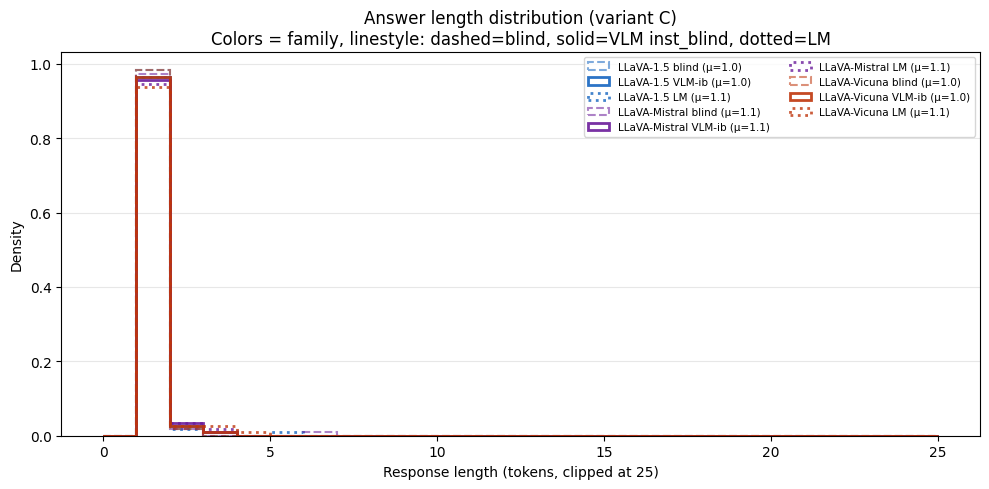

In [9]:
# ── Answer length distribution ────────────────────────────────────────────────
# Single plot: family = color, condition = linestyle

C_df = combined[combined['variant'] == 'C']
fig, ax = plt.subplots(figsize=(10, 5))

for fam, d in FAMILIES.items():
    vlm, lm = d['VLM'], d['LM']
    color = FAM_COLORS[fam]
    for key, mask in [
        ('blind',      (C_df['model']==vlm) & (C_df['condition']=='blind')),
        ('inst_blind', (C_df['model']==vlm) & (C_df['condition']=='inst_blind')),
        ('lm',         (C_df['model']==lm)  & (C_df['condition']=='inst_blind')),
    ]:
        vals = C_df[mask]['resp_len'].dropna().clip(upper=25)
        if vals.empty: continue
        sty = COND_STYLE[key]
        ax.hist(vals, bins=range(0,26), density=True,
                histtype='step', lw=sty['lw'], ls=sty['ls'],
                color=color, alpha=sty['alpha'],
                label=f'{fam} {"blind" if key=="blind" else ("VLM-ib" if key=="inst_blind" else "LM")} (μ={vals.mean():.1f})')

ax.set_xlabel('Response length (tokens, clipped at 25)')
ax.set_ylabel('Density')
ax.set_title('Answer length distribution (variant C)\n'
             'Colors = family, linestyle: dashed=blind, solid=VLM inst_blind, dotted=LM')
ax.legend(fontsize=7.5, ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

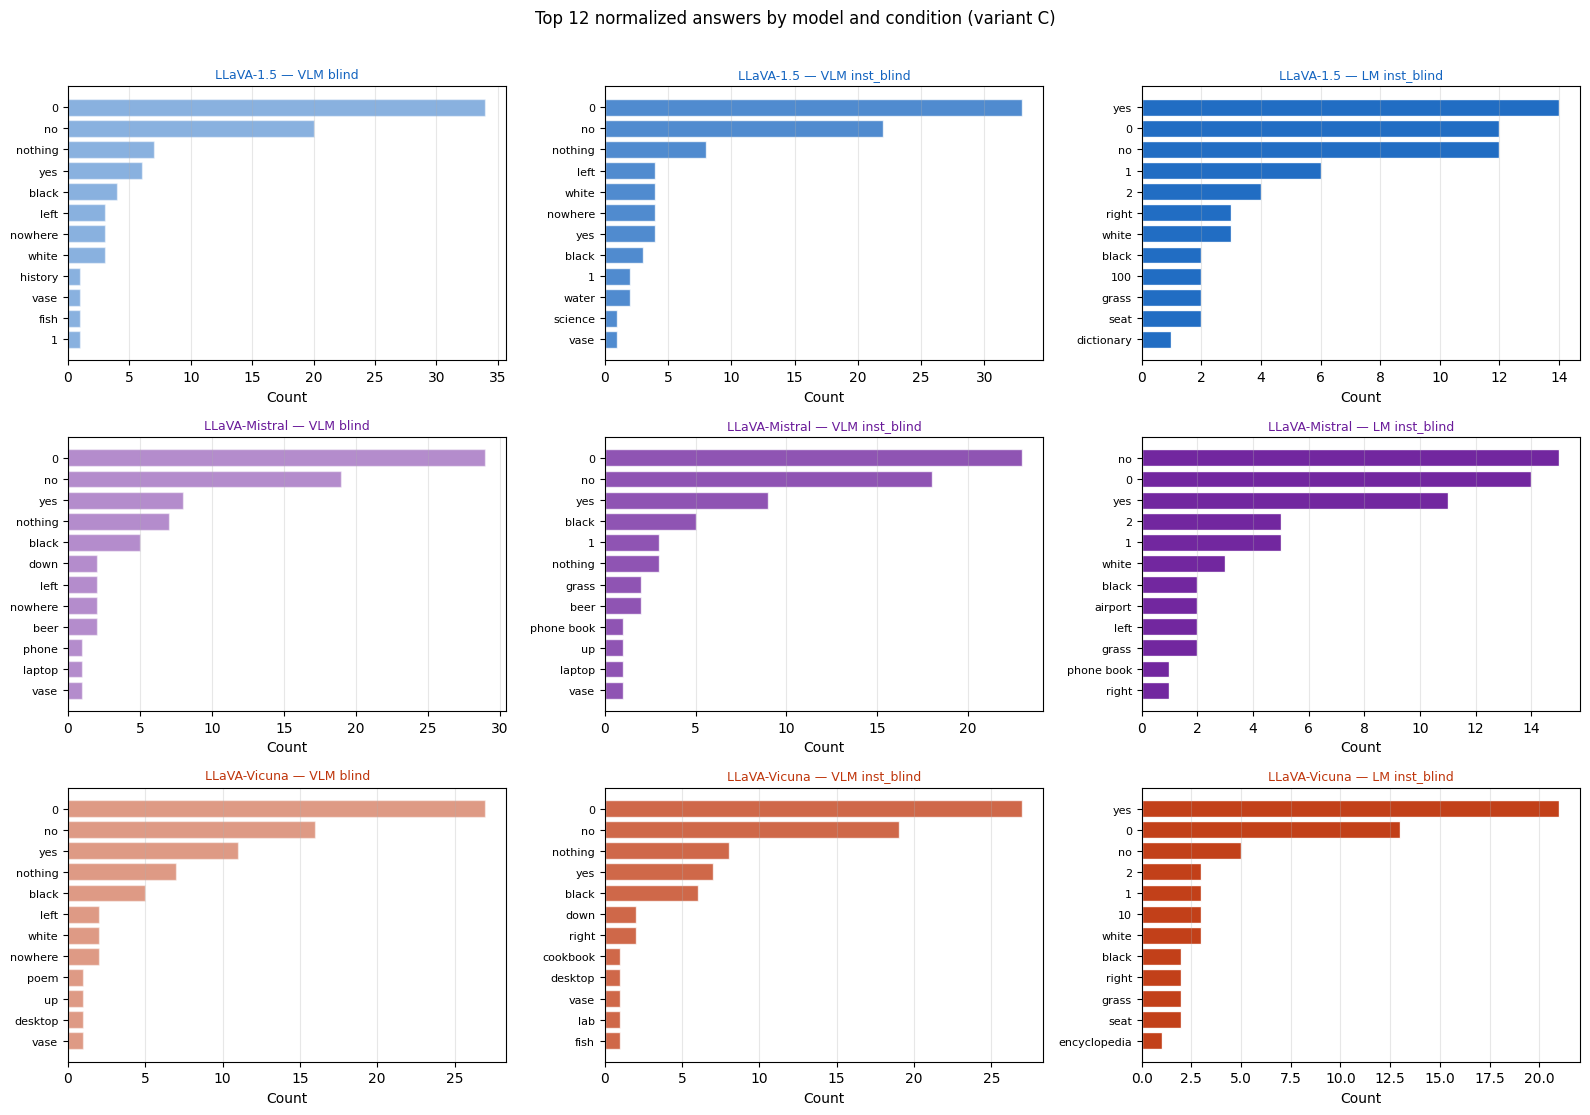

In [10]:
# ── Top answers per model per condition (3 × 3 grid) ─────────────────────────
TOP_N = 12
C_df = combined[combined['variant'] == 'C']

fig, axes = plt.subplots(3, 3, figsize=(16, 11))

for row_idx, (fam, d) in enumerate(FAMILIES.items()):
    vlm, lm = d['VLM'], d['LM']
    color = FAM_COLORS[fam]
    for col_idx, (label, mask, alpha) in enumerate([
        ('VLM blind',      (C_df['model']==vlm) & (C_df['condition']=='blind'),      0.5),
        ('VLM inst_blind', (C_df['model']==vlm) & (C_df['condition']=='inst_blind'), 0.75),
        ('LM inst_blind',  (C_df['model']==lm)  & (C_df['condition']=='inst_blind'), 0.95),
    ]):
        ax = axes[row_idx][col_idx]
        top = C_df[mask]['resp_norm'].value_counts().head(TOP_N)
        ax.barh(range(len(top))[::-1], top.values, color=color, alpha=alpha, edgecolor='white')
        ax.set_yticks(range(len(top))[::-1])
        ax.set_yticklabels(top.index, fontsize=8)
        ax.set_title(f'{fam} — {label}', fontsize=9, color=color)
        ax.set_xlabel('Count')
        ax.grid(axis='x', alpha=0.3)

plt.suptitle(f'Top {TOP_N} normalized answers by model and condition (variant C)',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

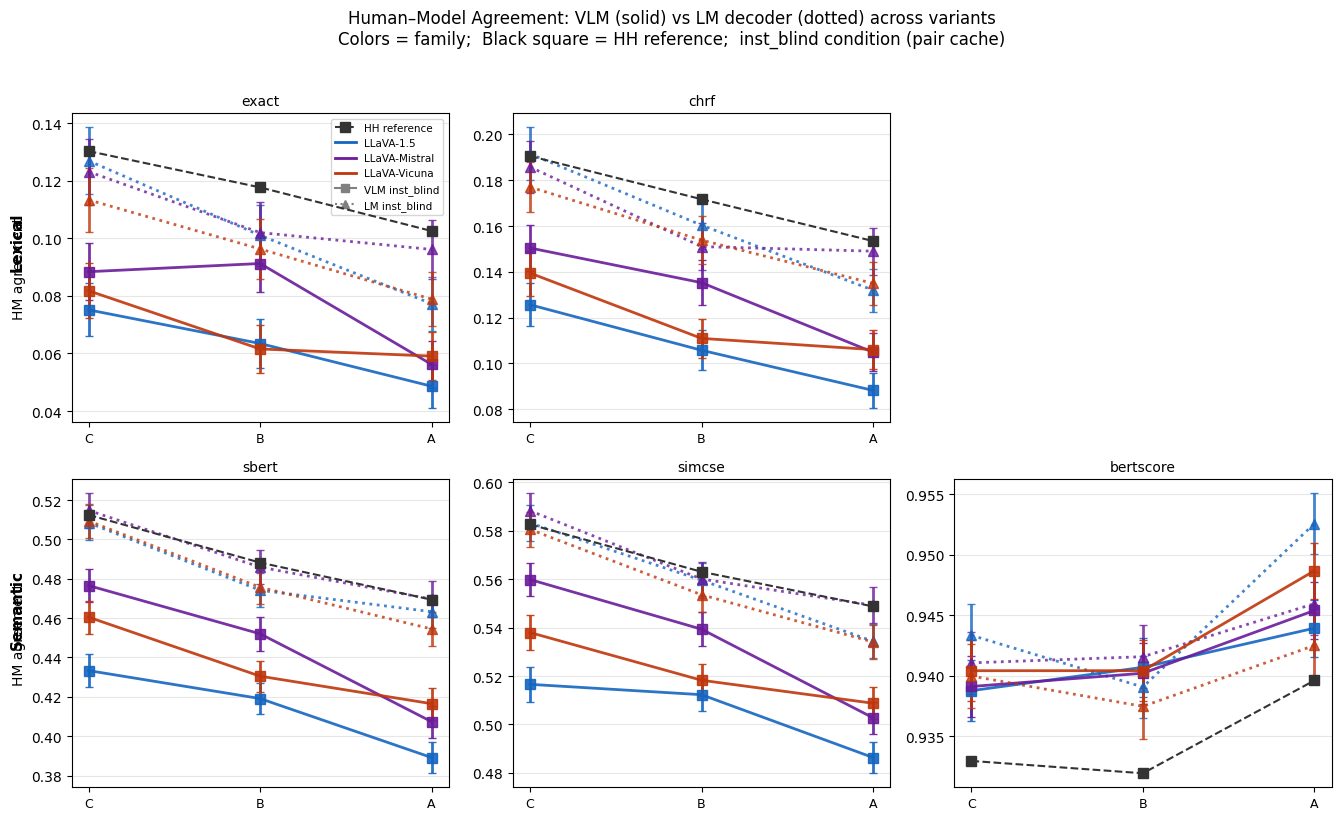

In [11]:
# ── Human–Model agreement: VLM vs LM from pair cache ─────────────────────────
# Layout: 2 rows (lexical / semantic) × n_metric cols, same as nb10c/10d
# Color = family, solid circle = VLM, dotted triangle = LM, black square = HH ref

pairs = pd.read_parquet(EXPORTS / 'pair_cache.parquet')
pairs['sbert']   = pairs['sbert_score_clip']
pairs['simcse']  = pairs['simcse_score_clip']
pairs['exact']   = pairs['exact_score']
pairs['chrf']    = pairs['chrf_score']
pairs['bertscore'] = pairs['bertscore_f1']

LEX_M = [m for m in ('exact','chrf') if m in pairs.columns]
SEM_M = [m for m in ('sbert','simcse','bertscore') if m in pairs.columns]
ALL_M = LEX_M + SEM_M
n_cols = max(len(LEX_M), len(SEM_M))

x = np.arange(len(VARIANT_ORDER))
fig, axes = plt.subplots(2, n_cols, figsize=(4.5 * n_cols, 8), sharey=False)

def plot_hm_row(axes_row, metrics):
    for ax, metric in zip(axes_row, metrics):
        # HH reference
        hh = [pairs[(pairs['pair_type']=='HH') & (pairs['variant']==v)][metric].mean()
              for v in VARIANT_ORDER]
        ax.plot(x, hh, 's--', color='#333333', lw=1.5, ms=7, label='HH ref', zorder=6)

        for fam, d in FAMILIES.items():
            color = FAM_COLORS[fam]
            for key, subject in [('inst_blind', d['VLM']), ('lm', d['LM'])]:
                means, cis = [], []
                for var in VARIANT_ORDER:
                    sub = pairs[(pairs['pair_type']=='HM') & (pairs['variant']==var) &
                                (pairs['subject_2']==subject)][metric]
                    means.append(sub.mean())
                    cis.append(sub.sem() * 1.96)
                sty = COND_STYLE[key]
                ax.errorbar(x, means, yerr=cis, color=color,
                            ls=sty['ls'], marker=sty['marker'],
                            lw=sty['lw'], ms=sty['ms'], alpha=sty['alpha'],
                            capsize=3)

        ax.set_xticks(x)
        ax.set_xticklabels(['C', 'B', 'A'], fontsize=9)
        ax.set_title(metric, fontsize=10)
        ax.grid(axis='y', alpha=0.3)
    for ax in axes_row[len(metrics):]:
        ax.set_visible(False)

axes[0,0].set_ylabel('HM agreement')
plot_hm_row(axes[0], LEX_M)
fig.text(0.01, 0.73, 'Lexical', va='center', rotation='vertical', fontsize=11, fontweight='bold')

axes[1,0].set_ylabel('HM agreement')
plot_hm_row(axes[1], SEM_M)
fig.text(0.01, 0.27, 'Semantic', va='center', rotation='vertical', fontsize=11, fontweight='bold')

# Shared legend
legend_handles = (
    [Line2D([0],[0], color='#333', marker='s', ls='--', lw=1.5, ms=7, label='HH reference')] +
    [Line2D([0],[0], color=FAM_COLORS[f], lw=2, label=f) for f in FAMILIES] +
    [Line2D([0],[0], color='gray', ls=COND_STYLE[k]['ls'], marker=COND_STYLE[k]['marker'],
             lw=1.5, ms=6, label={'inst_blind':'VLM inst_blind','lm':'LM inst_blind'}[k])
     for k in ('inst_blind','lm')]
)
axes[0,0].legend(handles=legend_handles, fontsize=7.5)

plt.suptitle('Human–Model Agreement: VLM (solid) vs LM decoder (dotted) across variants\n'
             'Colors = family;  Black square = HH reference;  inst_blind condition (pair cache)',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

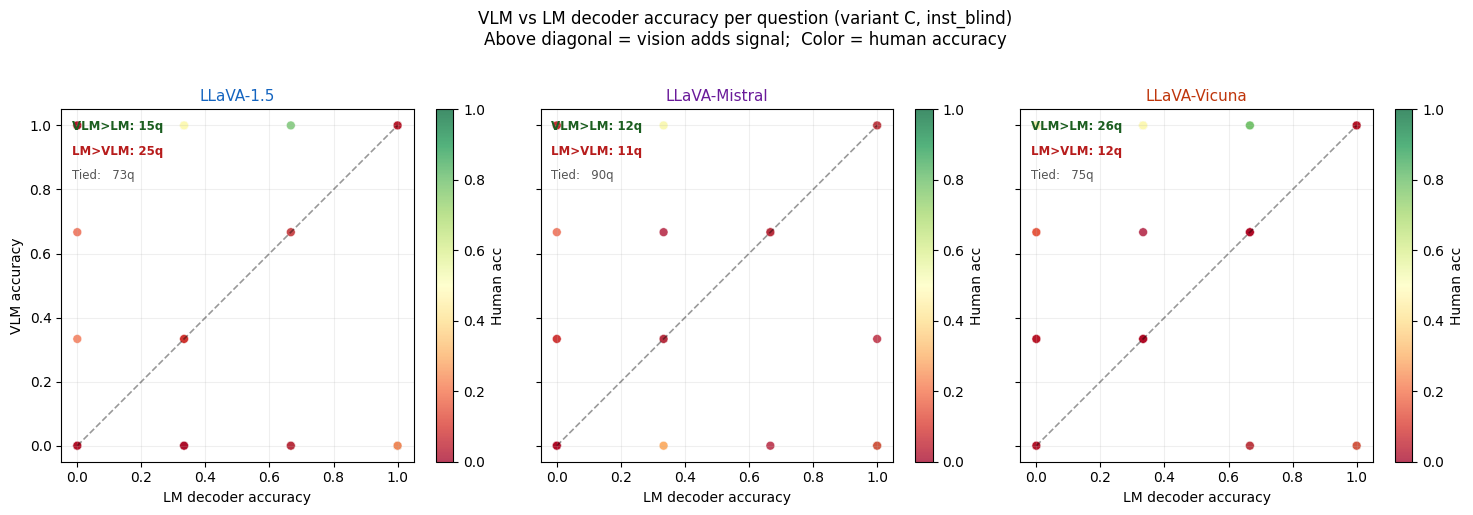

In [7]:
# ── Per-question: VLM acc vs LM acc (does vision add signal?) ────────────────
# 3 panels (one per family) — scatter is inherently per-family
# Color = human accuracy (green=easy, red=hard)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)

for ax, (fam, d) in zip(axes, FAMILIES.items()):
    vlm, lm = d['VLM'], d['LM']

    vlm_acc = (inst_vlm[(inst_vlm['model']==vlm) & (inst_vlm['variant']=='C')]
               .set_index('question_id')[['accuracy','human_avg_acc']])
    lm_acc  = (inst_lm[(inst_lm['model']==lm) & (inst_lm['variant']=='C')]
               .set_index('question_id')['accuracy'].rename('lm_acc'))
    merged  = vlm_acc.join(lm_acc, how='inner').dropna()
    merged.columns = ['vlm_acc', 'human_acc', 'lm_acc']

    sc = ax.scatter(merged['lm_acc'], merged['vlm_acc'],
                    c=merged['human_acc'], cmap='RdYlGn', vmin=0, vmax=1,
                    s=40, alpha=0.75, edgecolors='white', lw=0.4)
    ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.4)

    vlm_wins = (merged['vlm_acc'] > merged['lm_acc']).sum()
    lm_wins  = (merged['lm_acc'] > merged['vlm_acc']).sum()
    tied     = (merged['vlm_acc'] == merged['lm_acc']).sum()

    ax.text(0.03, 0.97, f'VLM>LM: {vlm_wins}q', transform=ax.transAxes,
            va='top', fontsize=8.5, color='#1B5E20', fontweight='bold')
    ax.text(0.03, 0.90, f'LM>VLM: {lm_wins}q', transform=ax.transAxes,
            va='top', fontsize=8.5, color='#B71C1C', fontweight='bold')
    ax.text(0.03, 0.83, f'Tied:   {tied}q',     transform=ax.transAxes,
            va='top', fontsize=8.5, color='#555')

    ax.set_xlabel('LM decoder accuracy')
    ax.set_title(fam, color=FAM_COLORS[fam], fontsize=11)
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.2)
    plt.colorbar(sc, ax=ax, label='Human acc')

axes[0].set_ylabel('VLM accuracy')
plt.suptitle('VLM vs LM decoder accuracy per question (variant C, inst_blind)\n'
             'Above diagonal = vision adds signal;  Color = human accuracy',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

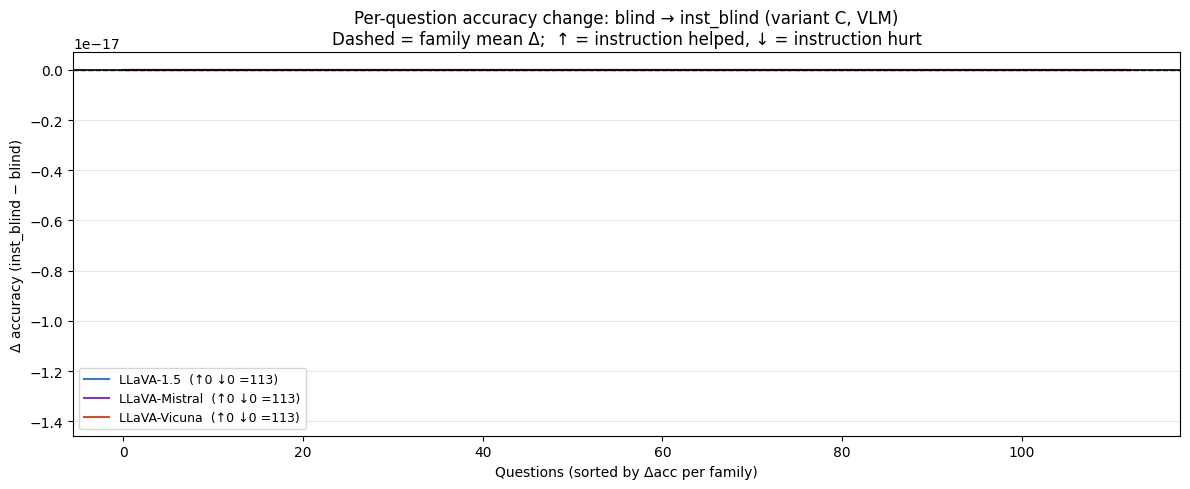

In [8]:
# ── Instruction effect: Δacc per question (blind → inst_blind) ────────────────
# Single combined plot: all families on same axes, each as sorted Δacc line

fig, ax = plt.subplots(figsize=(12, 5))

for fam, d in FAMILIES.items():
    vlm = d['VLM']
    color = FAM_COLORS[fam]

    bl = (blind_llava[(blind_llava['model']==vlm) & (blind_llava['variant']=='C')]
          .set_index('question_id')['accuracy'])
    ib = (inst_vlm[(inst_vlm['model']==vlm) & (inst_vlm['variant']=='C')]
          .set_index('question_id')['accuracy'])
    common = bl.index.intersection(ib.index)
    delta  = (ib[common] - bl[common]).sort_values().values

    n_pos = (delta > 0).sum(); n_neg = (delta < 0).sum()
    ax.plot(range(len(delta)), delta, color=color, lw=1.5, alpha=0.85,
            label=f'{fam}  (↑{n_pos} ↓{n_neg} ={len(delta)-n_pos-n_neg})')
    ax.axhline(delta.mean(), color=color, lw=1, ls='--', alpha=0.5)

ax.axhline(0, color='black', lw=1.2)
ax.fill_between(range(len(delta)), 0, 0, alpha=0)   # dummy for layout
ax.set_xlabel('Questions (sorted by Δacc per family)')
ax.set_ylabel('Δ accuracy (inst_blind − blind)')
ax.set_title('Per-question accuracy change: blind → inst_blind (variant C, VLM)\n'
             'Dashed = family mean Δ;  ↑ = instruction helped, ↓ = instruction hurt')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()